# **Modeling**

[Загрузка данных](#Data-loading)

- [Baseline](#Baseline)
- [Tuned Logistic Regression](#Tuned-Logistic-Regression)
- [Logistic Regression with WoE features](#Logistic-Regression-with-WoE-features)
- [XGBoost Classifier](#XGBoost-Classifier)
- [CatBoost Classifier](#CatBoost-Classifier)

[Выводы](#Inference)

---

## Data loading

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
from scipy.stats import loguniform, uniform, randint

from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection   import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectFromModel, f_classif
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics           import confusion_matrix, classification_report, roc_auc_score, roc_curve

from src import *

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
config = get_config()

X = pd.read_csv(config.paths.train_file).drop(columns=['Unnamed: 0'])
y = X.pop(config.data.target_col)

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=config.data.test_size,
                                                    random_state=config.data.random_seed, 
                                                    stratify=(y if config.data.stratify else None))

final_models = []

print(f"X_train shape: {X_train.shape}, {X_train.shape[0] / X.shape[0] * 100}%")
print(f"X_test  shape: {X_test.shape},  {X_test.shape[0]  / X.shape[0] * 100}%")

X_train shape: (120000, 10), 80.0%
X_test  shape: (30000, 10),  20.0%


---

## Baseline

Logistic regression with balanced class weights and scaled features

In [3]:
config_baseline = get_config()

In [9]:
config_baseline.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = False
)

config_baseline.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_baseline.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = False
)

config_baseline.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_baseline.preprocessing.woe = WoEConfig(
    enabled = False
)

config_baseline.preprocessing.scaling = ScalingConfig(
    enabled = True
)

baseline_preprocessor_pipeline = create_preprocessing_pipeline(config_baseline)

In [10]:
# Just for visualization

baseline_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=baseline_preprocessor_pipeline.transform(X_train),
             columns=baseline_preprocessor_pipeline[:-3].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=baseline_preprocessor_pipeline.transform(X_test),
             columns=baseline_preprocessor_pipeline[:-3].get_feature_names_out())

print(f"{X_train_processed.shape[1]} features")
X_train_processed.describe()

10 features


,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
count,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05
mean,9.710751e-17,1.089499e-17,-2.842171e-18,9.237056e-18,2.782959e-17,6.821210e-17,-2.842171e-18,1.657933e-18,2.486900e-17,-5.210647e-18
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.539848e+00,-4.016220e-01,-2.419050e-02,-1.682529e-01,-6.661208e-01,-1.640107e+00,-8.986067e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
25%,-7.641784e-01,-2.845215e-01,-2.407370e-02,-1.681692e-01,-6.661208e-01,-6.714281e-01,-8.986067e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
50%,-1.948666e-02,-7.441024e-02,-2.358536e-02,-1.680780e-01,-6.661208e-01,-9.022109e-02,-1.603341e-02,-1.004455e-01,-5.787317e-02,-6.371509e-02
75%,7.252051e-01,1.550141e-01,-2.198877e-02,-1.678418e-01,2.369816e-01,4.909859e-01,8.665398e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
max,3.839371e+00,2.259198e+02,2.001176e+02,1.572869e+02,1.739593e+01,9.596563e+00,4.676035e+01,2.333265e+01,2.358763e+01,2.350404e+01


In [11]:
baseline_model_pipeline = Pipeline(
    [
        ('preprocessing', baseline_preprocessor_pipeline),
        ('logreg', LogisticRegression(class_weight='balanced', random_state=42))
    ]
)

In [12]:
cv_scores = cross_val_score(
    baseline_model_pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Mean CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Mean CV AUC: 0.7904 ± 0.0053


In [13]:
baseline_model_pipeline.fit(X_train, y_train)

y_pred_test = baseline_model_pipeline.predict(X_test)

y_pred_proba_test = baseline_model_pipeline.predict_proba(X_test)[:, 1]

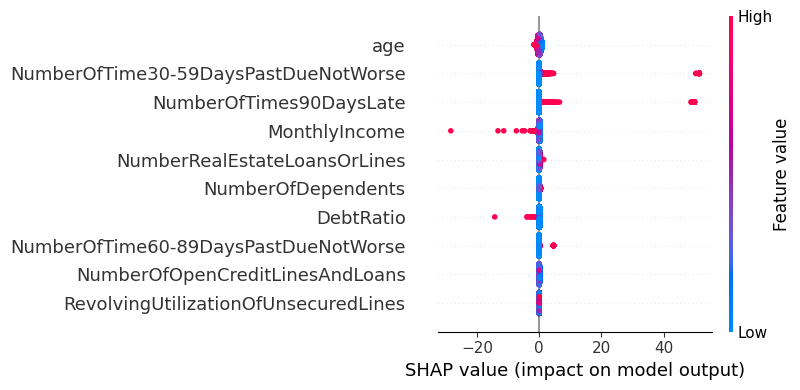

In [14]:
explainer = shap.LinearExplainer(baseline_model_pipeline[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 4))
plt.show()

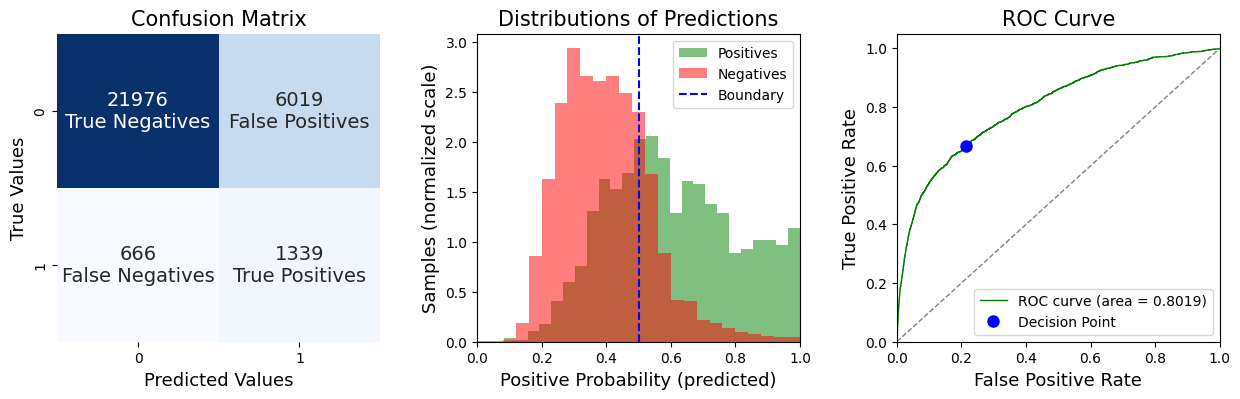


Precision: 0.18 | Recall: 0.67 | F1 Score: 0.29


In [15]:
eval_binary_classifier(baseline_model_pipeline, X_test, y_test);
final_models.append(('logreg_baseline', baseline_model_pipeline))

---

## **Tuned Logistic Regression**

In [11]:
config_logreg = get_config()

In [12]:
config_logreg.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_logreg.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = True
)

config_logreg.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True
)

config_logreg.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = True
)

config_logreg.preprocessing.woe = WoEConfig(
    enabled = False
)

config_logreg.preprocessing.scaling = ScalingConfig(
    enabled = True
)

logreg_preprocessor_pipeline = create_preprocessing_pipeline(config_logreg)

In [13]:
# Just for visualization

logreg_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=logreg_preprocessor_pipeline.transform(X_train),
             columns=logreg_preprocessor_pipeline[:-2].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=logreg_preprocessor_pipeline.transform(X_test),
             columns=logreg_preprocessor_pipeline[:-2].get_feature_names_out())

print(f"{X_train_processed.shape[1]} features")
X_train_processed.describe()

38 features


,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,high_debt_low_income,age^2,age^3,MonthlyIncome^2,MonthlyIncome^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,income_per_person,total_delinquencies,has_delinquency,weighted_delinquencies
count,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05
mean,-1.548983e-16,-1.288451e-16,-3.836931e-17,8.052818e-18,1.681618e-17,-9.687066e-17,6.833053e-17,3.931670e-17,2.321106e-17,-1.989520e-17,7.579123e-18,-4.121148e-17,3.552714e-18,-4.808006e-17,4.002724e-17,2.794801e-17,-1.042129e-17,-2.510584e-17,6.158037e-17,6.335673e-17,-1.657933e-17,-2.048732e-17,-6.631732e-18,-2.794801e-17,9.900229e-17,-8.242296e-17,9.331795e-17,1.551352e-16,-2.048732e-17,-1.136868e-17,-9.710751e-18,-2.107943e-17,-2.273737e-17,2.984279e-17,1.975309e-16,1.089499e-17,-1.835569e-17,4.926430e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.126884e+00,-1.271676e+00,-9.121156e-01,-9.911151e-01,-6.803752e-01,-1.689370e+00,-1.007904e+00,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.961175e-01,-1.499830e-01,-2.708587e-01,-8.177588e-01,-4.976682e-01,-1.686828e-01,-4.978246e-01,-1.281886e-01,-1.575551e+00,-1.200371e+00,-8.554517e-01,-6.650460e-01,-2.694881e-01,-1.185216e-01,-8.574814e-01,-5.488650e-01,-6.348305e-01,-4.277433e-01,-1.070072e+00,-3.809332e-01,-5.040073e-01,-3.367521e-01
25%,-7.660726e-01,-8.535315e-01,-8.273641e-01,-4.914311e-01,-6.803752e-01,-6.867944e-01,-1.007904e+00,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.961175e-01,-1.499830e-01,-2.708587e-01,-8.177588e-01,-4.976682e-01,-1.686828e-01,-4.978246e-01,-1.281886e-01,-7.959533e-01,-7.736421e-01,-7.983014e-01,-6.572437e-01,-2.355444e-01,-1.167381e-01,-6.338409e-01,-4.975484e-01,-6.348305e-01,-4.277433e-01,-7.841821e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
50%,-1.762647e-02,-1.032617e-01,-4.730253e-01,-1.714404e-01,-6.803752e-01,-8.524901e-02,7.641983e-03,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.961175e-01,-1.499830e-01,-2.708587e-01,-8.177588e-01,-4.976682e-01,-1.686828e-01,-4.978246e-01,-1.281886e-01,-1.527851e-01,-2.608875e-01,-4.092214e-01,-4.948166e-01,-1.781501e-01,-1.106493e-01,-2.849616e-01,-3.386722e-01,-3.100467e-01,-3.369442e-01,-2.269105e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
75%,7.308196e-01,7.159715e-01,6.854645e-01,1.879302e-01,2.537891e-01,5.162964e-01,1.023188e+00,-3.692201e-01,-2.1

In [6]:
logreg_model_pipeline = Pipeline(
    [
        ('preprocessing', logreg_preprocessor_pipeline),
        ('logreg', LogisticRegression(random_state=42,
                                      solver='saga',
                                      max_iter=5000,
                                      class_weight='balanced'))
    ]
)

In [13]:
param_grid_v1 = {
    'logreg__C': [2500, 5000, 7500],
    'logreg__l1_ratio': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
}

grid_search_v1 = GridSearchCV(
    estimator=logreg_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v1.best_params_)
print(f"Best cross-validated AUC: {grid_search_v1.best_score_:.4f}")

best_logreg = grid_search_v1.best_estimator_

y_pred_test = best_logreg.predict(X_test)
y_pred_proba_test = best_logreg.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'logreg__C': 2500, 'logreg__l1_ratio': 0.0}
Best cross-validated AUC: 0.8615
Test AUC: 0.8655


In [167]:
param_grid_v2 = {
    'logreg__C': [2250, 2500, 2750],
    'logreg__l1_ratio': [0.0, 0.01],
}

grid_search_v2 = GridSearchCV(
    estimator=logreg_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v2.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v2.best_params_)
print(f"Best cross-validated AUC: {grid_search_v2.best_score_:.4f}")

best_logreg = grid_search_v2.best_estimator_

y_pred_test = best_logreg.predict(X_test)
y_pred_proba_test = best_logreg.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'logreg__C': 2500, 'logreg__l1_ratio': 0.0}
Best cross-validated AUC: 0.8615
Test AUC: 0.8655


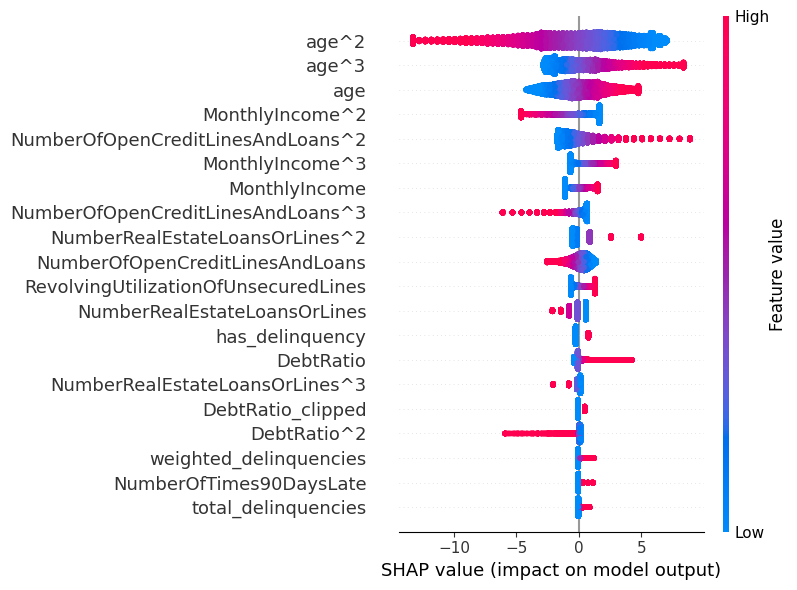

In [7]:
explainer = shap.LinearExplainer(best_logreg[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

In [16]:
selector = SelectFromModel(
    estimator=best_logreg[-1],
    threshold="0.1*mean",
)

selected_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_mask]

print(f"\nNumber of selected features: {len(selected_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(selected_features))

excluded_features = [excluded for excluded in X_train_processed.columns if excluded not in selected_features]
print(f"\n\nNumber of excluded features: {len(excluded_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(excluded_features))


Number of selected features: 27 / 38:

age, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines, DebtRatio, NumberOfDependents, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, MonthlyIncome_missing, is_senior, utilization_99999990, DebtRatio_clipped, DebtRatio_whole, high_debt_low_income, age^2, age^3, MonthlyIncome^2, MonthlyIncome^3, DebtRatio^2, DebtRatio^3, NumberOfOpenCreditLinesAndLoans^2, NumberOfOpenCreditLinesAndLoans^3, NumberRealEstateLoansOrLines^2, NumberRealEstateLoansOrLines^3, income_per_person, has_delinquency, weighted_delinquencies


Number of excluded features: 11 / 38:

NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfDependents_missing, is_young, MonthlyIncome_clipped, MonthlyIncome_zero, LowIncome, utilization_clipped, DebtRatio_low, DebtRatio_zero, total_delinquencies


In [9]:
final_logreg = best_logreg[-1].__class__(**best_logreg[-1].get_params())

final_logreg_pipeline = Pipeline([
    ('preprocessing', logreg_preprocessor_pipeline),
    ('feature_selection', selector),
    ('logreg', final_logreg)
])

cv_scores = cross_val_score(
    final_logreg_pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Mean CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

final_logreg_pipeline.fit(X_train, y_train)

y_pred_test = final_logreg_pipeline.predict(X_test)
y_pred_proba_test = final_logreg_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Mean CV AUC: 0.8620 ± 0.0039
Test AUC: 0.8655


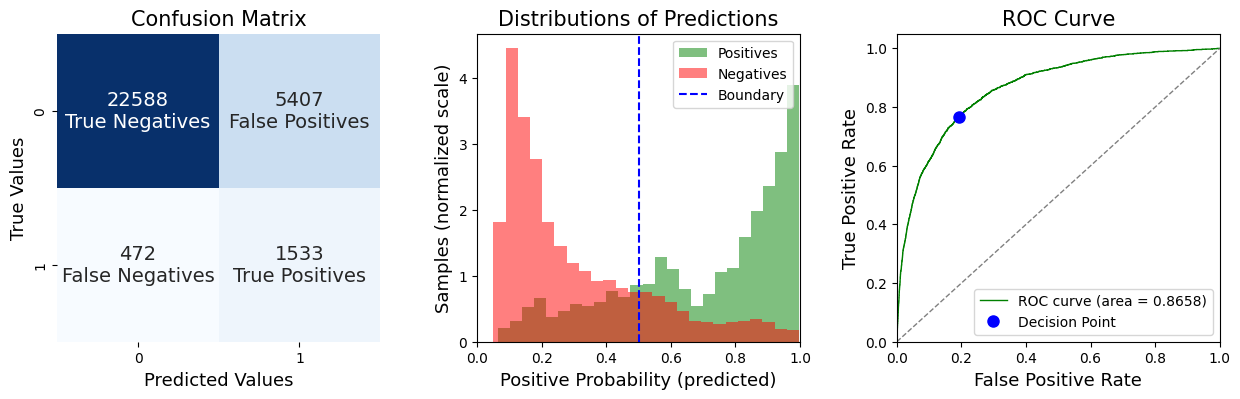


Precision: 0.22 | Recall: 0.76 | F1 Score: 0.34


In [66]:
eval_binary_classifier(final_logreg_pipeline, X_test, y_test);
final_models.append(('logreg_tuned', final_logreg_pipeline))

---

## **Logistic Regression with WoE features**

In [20]:
config_woe = get_config()

In [21]:
config_woe.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_woe.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_woe.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True,
    
    add_age_polynomial = False,
    add_debt_ratio_polynomial = False,
    add_loans_polynomial = False,
    add_estate_polynomial = False,
    add_income_polynomial = False,
)

config_woe.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_woe.preprocessing.woe = WoEConfig(
    enabled = True
)

config_woe.preprocessing.scaling = ScalingConfig(
    enabled = False
)

woe_preprocessor_pipeline = create_preprocessing_pipeline(config_woe)

In [22]:
# Just for visualization

woe_preprocessor_pipeline.fit(X_train, y_train)
 
X_train_processed = pd.DataFrame(data=woe_preprocessor_pipeline.transform(X_train),
             columns=woe_preprocessor_pipeline[:-1].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=woe_preprocessor_pipeline.transform(X_test),
             columns=woe_preprocessor_pipeline[:-1].get_feature_names_out())

print(f"{X_train_processed.shape[1]} features")
X_train_processed.describe()

28 features


,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,high_debt_low_income,income_per_person,total_delinquencies,has_delinquency,weighted_delinquencies
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,0.119613,0.038515,0.479573,0.046146,0.014631,0.030452,0.025145,0.259433,0.175357,0.247990,0.197292,0.026067,0.059025,0.321858,0.080275,0.011017,0.080617,0.022000,0.068350,0.400742,0.198508,0.027667,0.198608,0.016167,0.049120,0.489826,0.202567,0.496143
std,0.557193,0.295673,1.012301,0.290125,0.180954,0.246919,0.240158,0.660824,0.509972,0.611772,0.397956,0.159334,0.235672,0.467191,0.271720,0.104381,0.272247,0.146684,0.252347,0.490051,0.398879,0.164017,0.398954,0.126117,0.328263,0.930763,0.401914,0.931351
min,-0.586482,-0.491877,-1.423685,-0.670645,-0.438665,-0.740197,-0.279258,-2.411804,-2.731708,-3.131201,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.675220,-2.032827,0.000000,-2.128237
25%,-0.337911,-0.213578,-0.386744,0.000000,-0.113074,0.068287,-0.237867,0.534790,0.290411,0.392866,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.077495,0.932774,0.000000,0.932774
50%,-0.182991,0.216916,0.815023,0.120107,0.152846,0.136353,0.194703,0.534790,0.290411,0.392866,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145606,0.932774,0.000000,0.932774
75%,0.412289,0.225662,1.398403,0.120107,0.152846,0.136353,0.262158,0.534790,0.290411,0.392866,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.238600,0.932774,0.000000,0.932774
max,1.200175,0.469508,1.398403,0.643789,0.152846,0.136353,0.262158,0.534790,0.290411,0.392866,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.574230,0.932774,1.000000,0.932774


In [17]:
woe_model_pipeline = Pipeline(
    [
        ('preprocessing', woe_preprocessor_pipeline),
        ('logreg', LogisticRegression(random_state=42,
                                      solver='saga',
                                      max_iter=5000,
                                      class_weight='balanced'))
    ]
)

In [93]:
param_grid_v1 = {
    'logreg__C': [4000, 5000, 6000],
    'logreg__l1_ratio': [0.0, 0.4, 0.8, 0.9, 1.0],
}

grid_search_v1 = GridSearchCV(
    estimator=woe_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v1.best_params_)
print(f"Best cross-validated AUC: {grid_search_v1.best_score_:.4f}")

best_logreg_woe = grid_search_v1.best_estimator_

y_pred_test = best_logreg_woe.predict(X_test)
y_pred_proba_test = best_logreg_woe.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'logreg__C': 4000, 'logreg__l1_ratio': 0.9}
Best cross-validated AUC: 0.8586
Test AUC: 0.8617


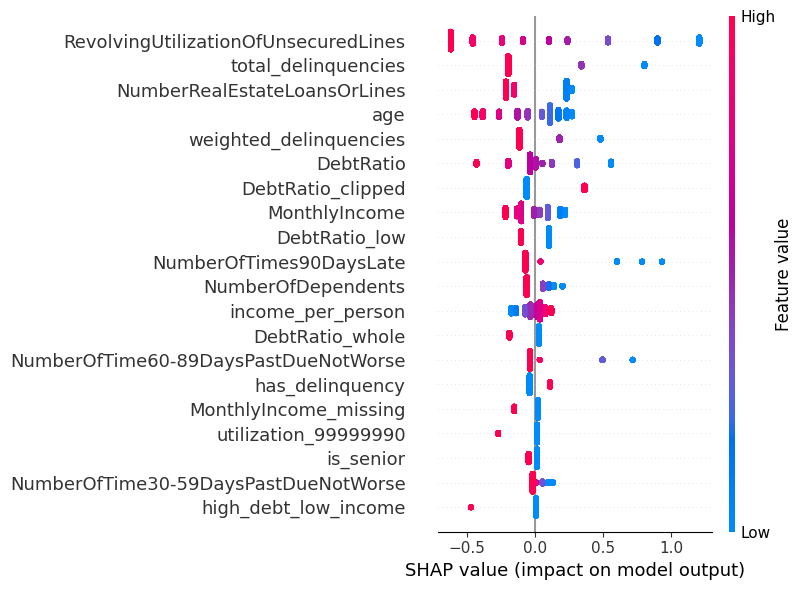

In [33]:
explainer = shap.LinearExplainer(best_logreg_woe[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

In [26]:
selector = SelectFromModel(
    estimator=best_logreg_woe[-1],
    threshold="0.1*mean",
)

selected_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_mask]

print(f"\nNumber of selected features: {len(selected_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(selected_features))

excluded_features = [excluded for excluded in X_train_processed.columns if excluded not in selected_features]
print(f"\n\nNumber of excluded features: {len(excluded_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(excluded_features))


Number of selected features: 25 / 28:

age, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines, DebtRatio, NumberOfDependents, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate, MonthlyIncome_missing, NumberOfDependents_missing, is_senior, MonthlyIncome_clipped, MonthlyIncome_zero, utilization_clipped, utilization_99999990, DebtRatio_low, DebtRatio_clipped, DebtRatio_whole, high_debt_low_income, income_per_person, total_delinquencies, has_delinquency, weighted_delinquencies


Number of excluded features: 3 / 28:

is_young, LowIncome, DebtRatio_zero


In [28]:
final_woe = best_logreg_woe[-1].__class__(**best_logreg_woe[-1].get_params())

final_woe_pipeline = Pipeline([
    ('preprocessing', woe_preprocessor_pipeline),
    ('feature_selection', selector),
    ('logreg', final_woe)
])

cv_scores = cross_val_score(
    final_woe_pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Mean CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

final_woe_pipeline.fit(X_train, y_train)

y_pred_test = final_woe_pipeline.predict(X_test)
y_pred_proba_test = final_woe_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Mean CV AUC: 0.8595 ± 0.0040
Test AUC: 0.8618


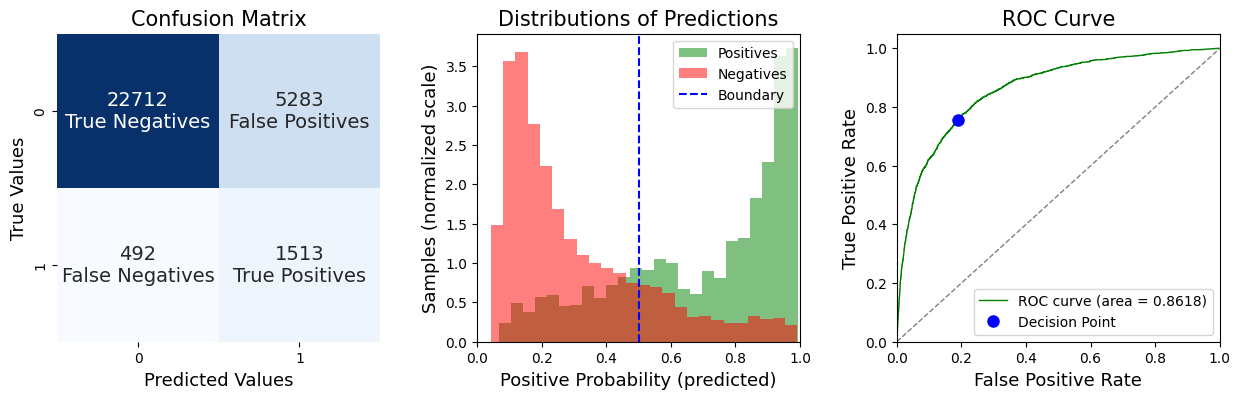


Precision: 0.22 | Recall: 0.75 | F1 Score: 0.34


In [67]:
eval_binary_classifier(final_woe_pipeline, X_test, y_test);
final_models.append(('logreg_woe', final_woe_pipeline))

---

## **XGBoost Classifier**

In [32]:
config_xgb = get_config()

In [33]:
config_xgb.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_xgb.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_xgb.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True,
    
    add_age_polynomial = False,
    add_debt_ratio_polynomial = False,
    add_loans_polynomial = False,
    add_estate_polynomial = False,
    add_income_polynomial = False,
)

config_xgb.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_xgb.preprocessing.woe = WoEConfig(
    enabled = False
)

config_xgb.preprocessing.scaling = ScalingConfig(
    enabled = False
)

xgb_preprocessor_pipeline = create_preprocessing_pipeline(config_xgb)

In [34]:
# Just for visualization

xgb_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=xgb_preprocessor_pipeline.transform(X_train),
             columns=xgb_preprocessor_pipeline[:-2].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=xgb_preprocessor_pipeline.transform(X_test),
             columns=xgb_preprocessor_pipeline[:-2].get_feature_names_out())

print(f"{X_train_processed.shape[1]} features")
X_train_processed.describe()

28 features


,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,high_debt_low_income,income_per_person,total_delinquencies,has_delinquency,weighted_delinquencies
count,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000
mean,52.287842,5.339220e+03,6.128916,352.271245,0.737592,8.465692,1.018167,0.420075,0.239858,0.264942,0.197292,0.026067,0.059025,0.321858,0.080275,0.011017,0.080617,0.022000,0.068350,0.400742,0.198508,0.027667,0.198608,0.016167,3.608949e+03,0.924875,0.202567,1.694617
std,14.771274,1.329420e+04,253.361490,2093.709509,1.107299,5.161693,1.133055,4.182138,4.144569,4.158242,0.397956,0.159334,0.235672,0.467191,0.271720,0.104381,0.272247,0.146684,0.252347,0.490051,0.398879,0.164017,0.398954,0.126117,8.201567e+03,12.434022,0.401914,24.863757
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,41.000000,1.556750e+03,0.029593,0.175330,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.640000e+02,0.000000,0.000000,0.000000
50%,52.000000,4.350000e+03,0.153318,0.366194,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.586583e+03,0.000000,0.000000,0.000000
75%,63.000000,7.400000e+03,0.557832,0.860833,1.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000e+03,0.000000,0.000000,0.000000
max,109.000000,3.008750e+06,50708.000000,329664.000000,20.000000,58.000000,54.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.794060e+06,294.000000,1.000000,588.000000


In [14]:
xgb_model_pipeline = Pipeline(
    [
        ('preprocessing', xgb_preprocessor_pipeline),
        ('xgb', XGBClassifier(
            random_state=42,
            scale_pos_weight=np.sum(y_train == 0) / np.sum(y_train == 1),
            eval_metric='auc',
            objective='binary:logistic',
            n_jobs=-1,
        ))
    ]
)

In [182]:
param_grid_v1 = {
    'xgb__n_estimators': [100, 200, 400],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.7, 1.0],
    'xgb__colsample_bytree': [0.7, 1.0],
}

grid_search_v1 = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2,
)

grid_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v1.best_params_)
print(f"Best cross-validated AUC: {grid_search_v1.best_score_:.4f}")

best_xgb = grid_search_v1.best_estimator_

y_pred_test = best_xgb.predict(X_test)
y_pred_proba_test = best_xgb.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 400, 'xgb__subsample': 0.7}
Best cross-validated AUC: 0.8652
Test AUC: 0.8698


In [113]:
param_grid_v2 = {
    'xgb__n_estimators': [250, 300, 350, 400],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.02, 0.03, 0.04],
    'xgb__subsample': [0.7, 0.75, 0.8],
    'xgb__colsample_bytree': [0.7, 0.75, 0.8],
    'xgb__reg_alpha': [0.1, 0.3, 0.5],
    'xgb__reg_lambda': [1.0, 1.5, 2.0],
}

grid_search_v2 = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_v2,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v2.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v2.best_params_)
print(f"Best cross-validated AUC: {grid_search_v2.best_score_:.4f}")

best_xgb = grid_search_v2.best_estimator_

y_pred_test = best_xgb.predict(X_test)
y_pred_proba_test = best_xgb.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.02, 'xgb__max_depth': 4, 'xgb__n_estimators': 400, 'xgb__reg_alpha': 0.3, 'xgb__reg_lambda': 1.0, 'xgb__subsample': 0.75}
Best cross-validated AUC: 0.8655
Test AUC: 0.8698


100%|===================| 29981/30000 [02:05<00:00]        

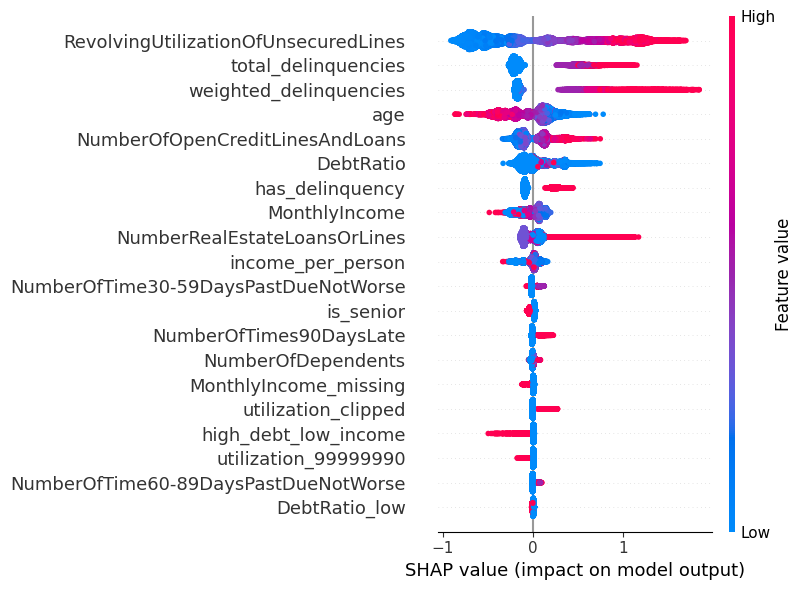

In [114]:
explainer = shap.TreeExplainer(best_xgb[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

In [36]:
selector = SelectFromModel(
    estimator=best_xgb[-1],
    threshold="0.1*mean",
)

selected_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_mask]

print(f"\nNumber of selected features: {len(selected_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(selected_features.tolist()))

excluded_features = [excluded for excluded in X_train_processed.columns if excluded not in selected_features]
print(f"\n\nNumber of excluded features: {len(excluded_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(excluded_features))


Number of selected features: 26 / 28:

age, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines, DebtRatio, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate, MonthlyIncome_missing, is_young, is_senior, MonthlyIncome_clipped, MonthlyIncome_zero, LowIncome, utilization_clipped, utilization_99999990, DebtRatio_low, DebtRatio_clipped, DebtRatio_zero, DebtRatio_whole, high_debt_low_income, income_per_person, total_delinquencies, has_delinquency, weighted_delinquencies


Number of excluded features: 2 / 28:

NumberOfDependents, NumberOfDependents_missing


In [37]:
final_xgb = best_xgb[-1].__class__(**best_xgb[-1].get_params())

final_xgb_pipeline = Pipeline([
    ('preprocessing', xgb_preprocessor_pipeline),
    ('feature_selection', selector),
    ('xgb', final_xgb)
])

cv_scores = cross_val_score(
    final_xgb_pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Mean CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

final_xgb_pipeline.fit(X_train, y_train)

y_pred_test = final_xgb_pipeline.predict(X_test)
y_pred_proba_test = final_xgb_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Mean CV AUC: 0.8666 ± 0.0032
Test AUC: 0.8699


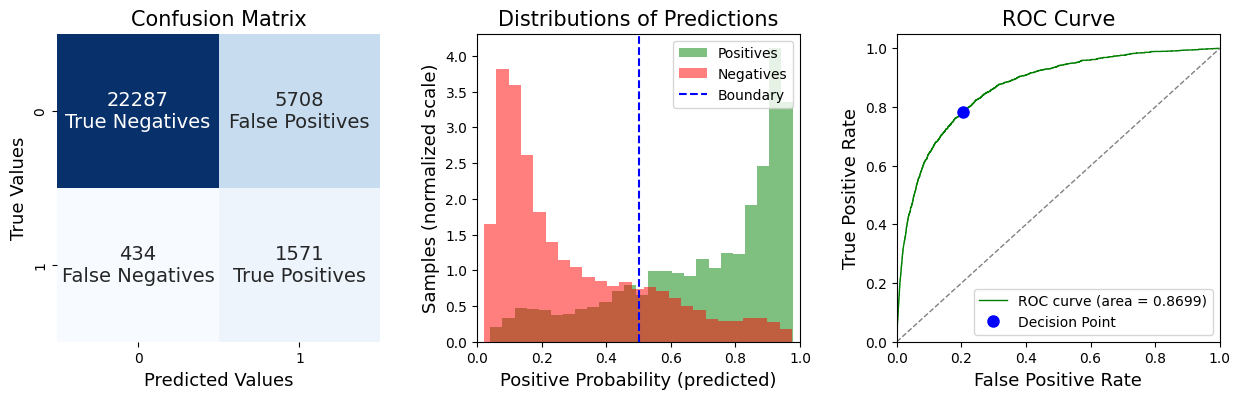


Precision: 0.22 | Recall: 0.78 | F1 Score: 0.34


In [68]:
eval_binary_classifier(final_xgb_pipeline, X_test, y_test);
final_models.append(('XGBoost', final_xgb_pipeline))

---

## **CatBoost Classifier**

In [40]:
config_catboost = get_config()

In [41]:
config_catboost.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_catboost.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_catboost.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True,
    
    add_age_polynomial = False,
    add_debt_ratio_polynomial = False,
    add_loans_polynomial = False,
    add_estate_polynomial = False,
    add_income_polynomial = False,
)

config_catboost.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_catboost.preprocessing.woe = WoEConfig(
    enabled = False
)

config_catboost.preprocessing.scaling = ScalingConfig(
    enabled = False
)

catboost_preprocessor_pipeline = create_preprocessing_pipeline(config_catboost)

In [42]:
# Just for visualization

catboost_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=catboost_preprocessor_pipeline.transform(X_train),
             columns=catboost_preprocessor_pipeline[:-2].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=catboost_preprocessor_pipeline.transform(X_test),
             columns=catboost_preprocessor_pipeline[:-2].get_feature_names_out())

print(f"{X_train_processed.shape[1]} features")
X_train_processed.describe()

28 features


,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,high_debt_low_income,income_per_person,total_delinquencies,has_delinquency,weighted_delinquencies
count,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000
mean,52.287842,5.339220e+03,6.128916,352.271245,0.737592,8.465692,1.018167,0.420075,0.239858,0.264942,0.197292,0.026067,0.059025,0.321858,0.080275,0.011017,0.080617,0.022000,0.068350,0.400742,0.198508,0.027667,0.198608,0.016167,3.608949e+03,0.924875,0.202567,1.694617
std,14.771274,1.329420e+04,253.361490,2093.709509,1.107299,5.161693,1.133055,4.182138,4.144569,4.158242,0.397956,0.159334,0.235672,0.467191,0.271720,0.104381,0.272247,0.146684,0.252347,0.490051,0.398879,0.164017,0.398954,0.126117,8.201567e+03,12.434022,0.401914,24.863757
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,41.000000,1.556750e+03,0.029593,0.175330,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.640000e+02,0.000000,0.000000,0.000000
50%,52.000000,4.350000e+03,0.153318,0.366194,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.586583e+03,0.000000,0.000000,0.000000
75%,63.000000,7.400000e+03,0.557832,0.860833,1.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000e+03,0.000000,0.000000,0.000000
max,109.000000,3.008750e+06,50708.000000,329664.000000,20.000000,58.000000,54.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.794060e+06,294.000000,1.000000,588.000000


In [18]:
catboost_model_pipeline = Pipeline([
    ('preprocessing', catboost_preprocessor_pipeline),
    ('catboost', CatBoostClassifier(
        random_state=42,
        auto_class_weights='Balanced',
        loss_function='Logloss',
        eval_metric='AUC',
        thread_count=-1,
        od_type = 'Iter',
        od_wait = 100,
        allow_writing_files=False,
        verbose=False,
    ))
])

In [9]:
param_random_v1 = {
    'catboost__iterations': randint(100, 1500),
    'catboost__learning_rate': uniform(0.01, 0.3),
    'catboost__depth': randint(3, 12),
    'catboost__l2_leaf_reg': uniform(1, 10),
    'catboost__border_count': randint(32, 255),
    'catboost__subsample': uniform(0.6, 0.4),
    'catboost__colsample_bylevel': uniform(0.6, 0.4),
}

random_search_v1 = RandomizedSearchCV(
    estimator=catboost_model_pipeline,
    param_distributions=param_random_v1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

random_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(random_search_v1.best_params_)
print(f"Best cross-validated AUC: {random_search_v1.best_score_:.4f}")

best_catboost = random_search_v1.best_estimator_

y_pred_test = best_catboost.predict(X_test)
y_pred_proba_test = best_catboost.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'catboost__border_count': 121, 'catboost__colsample_bylevel': np.float64(0.6390688456025535), 'catboost__depth': 6, 'catboost__iterations': 191, 'catboost__l2_leaf_reg': np.float64(5.4015249373960135), 'catboost__learning_rate': np.float64(0.04661147045343365), 'catboost__subsample': np.float64(0.798070764044508)}
Best cross-validated AUC: 0.8649
Test AUC: 0.8700


100%|===================| 29860/30000 [01:45<00:00]        

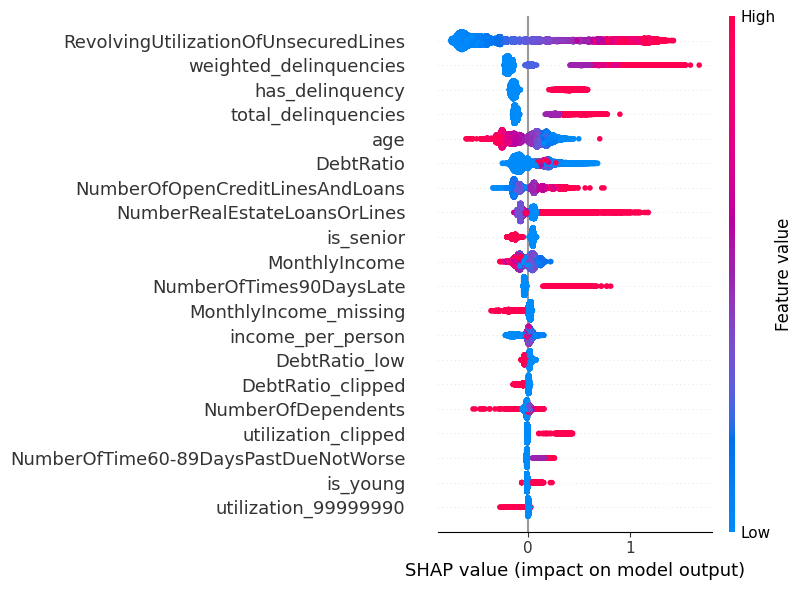

In [10]:
explainer = shap.TreeExplainer(best_catboost[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

In [44]:
selector = SelectFromModel(
    estimator=best_catboost[-1],
    threshold="0.1*mean",
)

selected_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_mask]

print(f"\nNumber of selected features: {len(selected_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(selected_features.tolist()))

excluded_features = [excluded for excluded in X_train_processed.columns if excluded not in selected_features]
print(f"\n\nNumber of excluded features: {len(excluded_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(excluded_features))


Number of selected features: 24 / 28:

age, MonthlyIncome, RevolvingUtilizationOfUnsecuredLines, DebtRatio, NumberOfDependents, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate, MonthlyIncome_missing, is_young, is_senior, utilization_clipped, utilization_99999990, DebtRatio_low, DebtRatio_clipped, DebtRatio_zero, DebtRatio_whole, high_debt_low_income, income_per_person, total_delinquencies, has_delinquency, weighted_delinquencies


Number of excluded features: 4 / 28:

NumberOfDependents_missing, MonthlyIncome_clipped, MonthlyIncome_zero, LowIncome


In [45]:
final_catboost = best_catboost[-1].__class__(**best_catboost[-1].get_params())

final_catboost_pipeline = Pipeline([
    ('preprocessing', catboost_preprocessor_pipeline),
    ('feature_selection', selector),
    ('catboost', final_catboost)
])

cv_scores = cross_val_score(
    final_catboost_pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Mean CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

final_catboost_pipeline.fit(X_train, y_train)

y_pred_test = final_catboost_pipeline.predict(X_test)
y_pred_proba_test = final_catboost_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Mean CV AUC: 0.8659 ± 0.0033
Test AUC: 0.8696


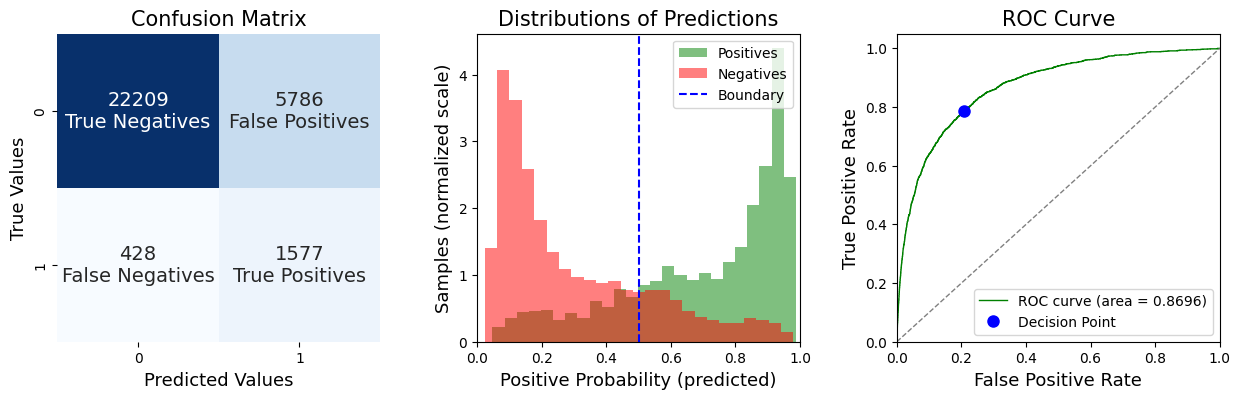


Precision: 0.21 | Recall: 0.79 | F1 Score: 0.34


In [69]:
eval_binary_classifier(final_catboost_pipeline, X_test, y_test);
final_models.append(('CatBoost', final_catboost_pipeline))

---

Сохраним все финальные модели:

In [97]:
for name, pipeline in final_models:
    filename = os.path.join(config.paths.models_dir, f'{name}.joblib')
    joblib.dump(pipeline, filename)

---

## Inference

**Все модели демонстрируют схожее качество предсказаний.** ROC-AUC варьируется в узком диапазоне 0.8618–0.8699, что указывает на хорошую способность моделей ранжировать заемщиков по уровню риска.

**Модели имеют высокую "чувствительность".** Recall ~75-78% означает, что алгоритмы успешно выявляют большинство потенциальных дефолтов. Однако это достигается ценой низкой точности (Precision ~21-22%) — каждый пятый заемщик, отмеченный моделью как рискованный, на самом деле окажется благонадежным.

**Градиентные бустинги не превзошли логистическую регрессию существенно.** XGBoost и CatBoost показали практически идентичные результаты (ROC-AUC 0.8699 и 0.8696 соответственно), но не продемонстрировали выдающегося преимущества перед значительно более простыми и интерпретируемыми моделями логистической регрессии.

In [99]:
evaluate_models(final_models_, X_test, y_test)

,Precision,Recall,F1 score,ROC-AUC
Model,,,,
XGBoost,0.2158,0.7835,0.3384,0.8699
CatBoost,0.2142,0.7865,0.3367,0.8696
logreg_tuned,0.2209,0.7646,0.3428,0.8658
logreg_woe,0.2226,0.7546,0.3438,0.8618
logreg_baseline,0.1820,0.6678,0.2860,0.8019


Текущие метрики получены при дефолтном пороге 0.5. В зависимости от бизнес-целей (минимизация потерь vs. максимизация одобрений) возможна **калибровка порога** отсечения с учетом стоимости ошибок первого и второго рода.

Учитывая требования стейкхолдеров к прозрачности моделей кредитного скоринга, на продакшене разумно рекомендовать логистическую регрессию с WoE как основную модель, с возможностью использования XGBoost в качестве альтернативного решения.